In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vivmankar/asian-vs-african-elephant-image-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'asian-vs-african-elephant-image-classification' dataset.
Path to dataset files: /kaggle/input/asian-vs-african-elephant-image-classification
Contents of base_path (/kaggle/input):
['asian-vs-african-elephant-image-classification']
Contents of path (/kaggle/input/asian-vs-african-elephant-image-classification):
['dataset']


In [ ]:
import os

# Update path to match the 'dataset' directory in the elephant dataset
data_path = os.path.join(path, 'dataset')

# List subdirectories (usually 'train' and 'test' classes)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['test', 'train']



--- Sample Images from Dataset (/kaggle/input/asian-vs-african-elephant-image-classification/dataset) ---
Found 1028 images. Displaying 6 sample images:


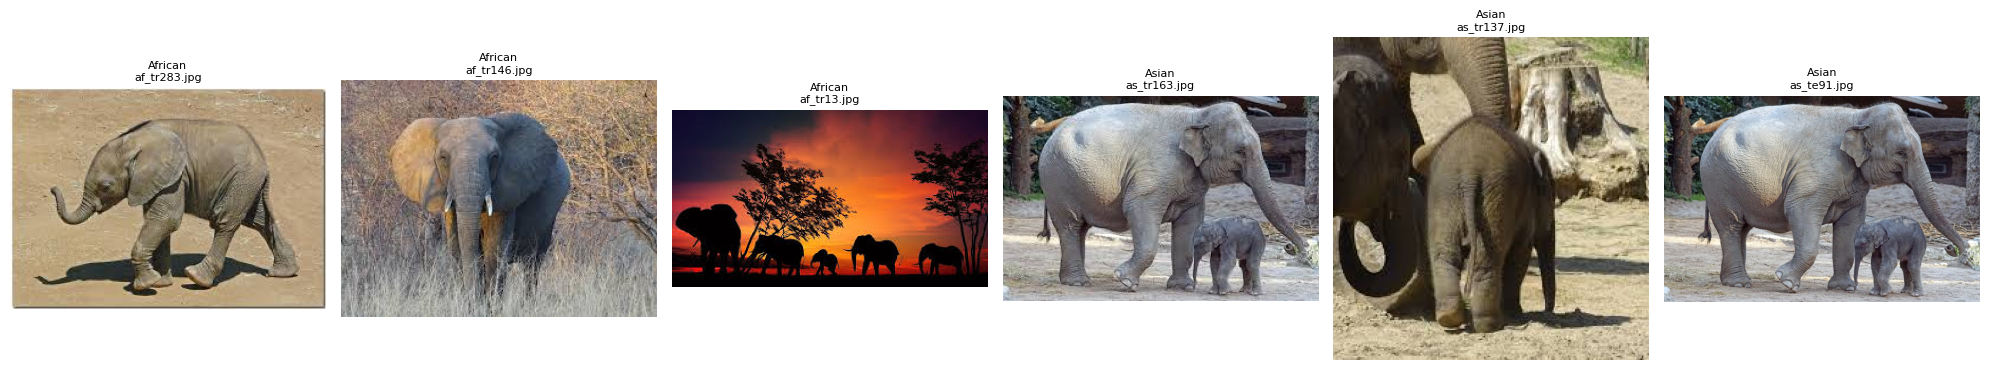

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent folder) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct 'dataset' path
data_path = os.path.join(path, 'dataset')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3, 1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3, 1), 'GB')

Using device: cpu


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')

train_dataset = datasets.ImageFolder(train_path, transform=transform)
test_dataset = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define AlexNet Model
class AlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
history = {'train_loss': [], 'train_acc': []}
epochs = 10

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}%")

Starting Training...
Epoch [1/10] Loss: 0.6956 Acc: 49.88%
Epoch [2/10] Loss: 0.6835 Acc: 56.67%
Epoch [3/10] Loss: 0.6777 Acc: 57.86%
Epoch [4/10] Loss: 0.6815 Acc: 59.29%
Epoch [5/10] Loss: 0.6583 Acc: 60.71%
Epoch [6/10] Loss: 0.6522 Acc: 61.31%
Epoch [7/10] Loss: 0.6477 Acc: 63.69%
Epoch [8/10] Loss: 0.6316 Acc: 63.69%
Epoch [9/10] Loss: 0.6236 Acc: 66.19%
Epoch [10/10] Loss: 0.6021 Acc: 69.05%


In [ ]:
# Model Evaluation Summary
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Test Accuracy: {100. * test_correct / test_total:.2f}%")

Final Training Accuracy: 69.05%
Test Accuracy: 78.19%


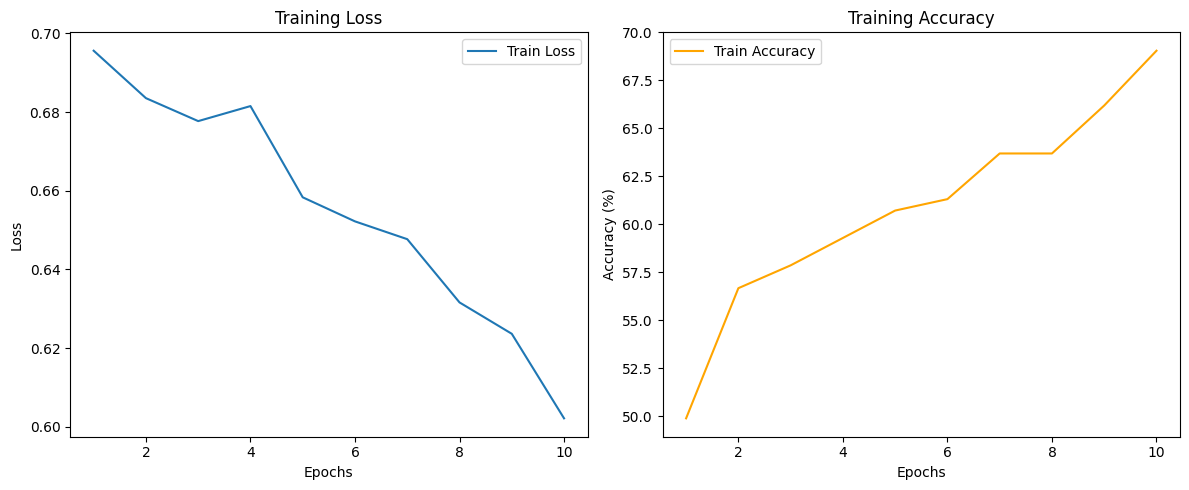

In [ ]:
import matplotlib.pyplot as plt

# Plot Training Progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], label='Train Accuracy', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()